# Evaluation 2/2 — LLM-as-Judge (7 counseling dimensions)

Judges a seeded sample of the **stored generations** from
`results/generations/` (produced by `evaluate_metric.ipynb` on the one
MentalChat16K test split — run that notebook's generation cell first). Every
system is judged on the SAME sampled questions, tuned and base alike, using
the MentalChat16K paper's 7-dimension rubric via GLM-4.7-Flash (free tier).

In [1]:
# Setup: client, stored generations, seeded judge sample
import os
os.environ["PYTHONUTF8"] = "1"

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)

import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

import evaluator
import ft_utils
import llm_judge

load_dotenv(ft_utils.ROOT.parent / ".env")
client = llm_judge.make_client()   # raises with instructions if GLM_API_KEY is empty

MODELS = list(ft_utils.CFG["models"])
VARIANTS = ("tuned", "base")
N_SAMPLES = ft_utils.CFG["judge"].get("n_samples", 200)
RESULTS = ft_utils.RESULTS_ROOT / "llm_judge"
RESULTS.mkdir(parents=True, exist_ok=True)

SYSTEMS = {}   # "gemma2_tuned" -> records
for mk in MODELS:
    for variant in VARIANTS:
        recs = evaluator.load_generations(mk, variant)
        if recs is None:
            print(f"  ! {mk}_{variant} not generated yet — run evaluate_metric.ipynb first")
        else:
            SYSTEMS[f"{mk}_{variant}"] = recs

sizes = {len(r) for r in SYSTEMS.values()}
assert SYSTEMS, "no stored generations found"
assert len(sizes) == 1, f"generation files disagree in length: {sizes}"
n_total = sizes.pop()

# One seeded sample of question indices, shared by every system (fair pairing)
rng = random.Random(ft_utils.SEED)
SAMPLE_IDX = sorted(rng.sample(range(n_total), min(N_SAMPLES, n_total)))
print(f"{len(SYSTEMS)} systems x {len(SAMPLE_IDX)} sampled questions "
      f"(of {n_total}) | judge: {llm_judge.JUDGE_MODEL}")

6 systems x 200 sampled questions (of 1470) | judge: glm-4.7-flash


In [2]:
# Judge smoke test (2 live calls) BEFORE spending on the batch
name, recs = next(iter(SYSTEMS.items()))
for idx in SAMPLE_IDX[:2]:
    rec = recs[idx]
    verdict = llm_judge.judge_one(client, rec["input"], rec["prediction"])
    print(f"[{name} #{idx}] Q: {rec['input'][:90]}...")
    print(f"  scores: {verdict['scores']}")
    print(f"  justification: {verdict['justification'][:140]}\n")
print("Smoke test OK — prompt, key, and parsing all work.")

[gemma2_tuned #1] Q: "Anxiety consumes me in social situations. Just the thought of speaking up in a group sett...
  scores: {'active_listening': 9.0, 'empathy_validation': 8.0, 'safety_trustworthiness': 9.0, 'openmindedness_nonjudgment': 9.0, 'clarity_encouragement': 9.0, 'boundaries_ethical': 9.0, 'holistic_approach': 7.0}
  justification: The response effectively validates the patient's physical and emotional symptoms and provides clear, actionable strategies, though it does n

[gemma2_tuned #6] Q: "Anxiety has consumed my life. I experience frequent panic attacks where I struggle to bre...
  scores: {'active_listening': 9.0, 'empathy_validation': 9.0, 'safety_trustworthiness': 7.0, 'openmindedness_nonjudgment': 10.0, 'clarity_encouragement': 8.0, 'boundaries_ethical': 6.0, 'holistic_approach': 7.0}
  justification: The response effectively validates the patient's distress and provides clear, actionable coping strategies, though it lacks a direct mention

Smoke test OK — prompt, key

In [3]:
# Judge every sampled response (incremental + resumable: verdicts append to
# scores_raw.jsonl as they arrive; already-judged ids are skipped on re-run)
items = []
for system, recs in SYSTEMS.items():
    for idx in SAMPLE_IDX:
        items.append((f"{system}__{idx}", recs[idx]["input"], recs[idx]["prediction"]))
print(f"{len(items)} judge calls (cost: $0 — expect ~{len(items) * 3 / 3600:.1f} h at free-tier pace)")

llm_judge.judge_many(client, items, RESULTS / "scores_raw.jsonl")

1200 judge calls (cost: $0 — expect ~1.0 h at free-tier pace)
1200 to judge (0 already in scores_raw.jsonl)
  1200/1200 judged


In [4]:
# Parse scores_raw.jsonl -> judge_scores.csv
rows, failures = [], []
with open(RESULTS / "scores_raw.jsonl", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if not rec.get("ok"):
            failures.append((rec["custom_id"], rec.get("error", "?")))
            continue
        system, idx = rec["custom_id"].rsplit("__", 1)
        model_key, variant = system.rsplit("_", 1)
        rows.append({"model": model_key, "variant": variant, "idx": int(idx),
                     **rec["scores"]})

scores = pd.DataFrame(rows).sort_values(["model", "variant", "idx"])
scores.to_csv(RESULTS / "judge_scores.csv", index=False)
print(f"{len(scores)} judgments parsed | {len(failures)} failures")
if failures:
    print("first failures:", failures[:5])
    print("re-run the judging cell to retry — delete failed lines from scores_raw.jsonl first")
scores.groupby(["model", "variant"])[llm_judge.DIMENSIONS].mean().round(2)

1200 judgments parsed | 0 failures


active_listening  empathy_validation  safety_trustworthiness  \
model   variant                                                                 
gemma2  base                 7.55                7.42                    8.39   
        tuned                7.79                7.04                    8.60   
llama32 base                 6.64                6.10                    8.14   
        tuned                7.80                7.07                    8.62   
qwen3   base                 8.11                8.24                    8.64   
        tuned                7.74                7.01                    8.63   

                 openmindedness_nonjudgment  clarity_encouragement  \
model   variant                                                      
gemma2  base                           9.22                   8.20   
        tuned                          9.10                   8.07   
llama32 base                           8.86                   7.70   
        tuned                          9.16                   7.99   
qwen3   base                           9.49                   8.26   
        tuned                          9.09                   8.03   

                 boundaries_ethical  holistic_approach  
model   variant                                         
gemma2  base                   7.66               6.36  
        tuned                  7.77               6.80  
llama32 base                   7.70               5.88  
        tuned                  7.89               6.84  
qwen3   base                   7.92               6.90  
        tuned                  7.87               6.86

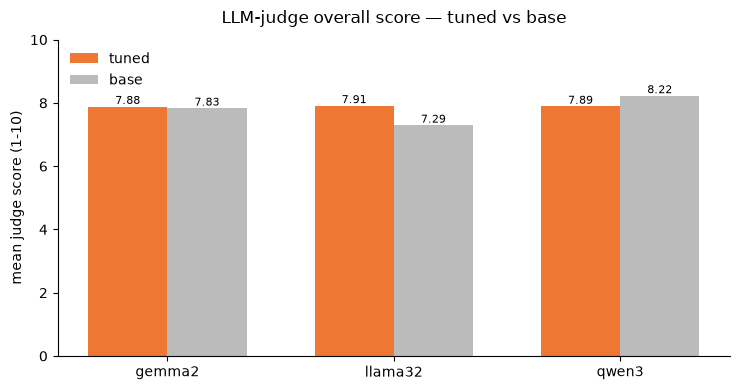

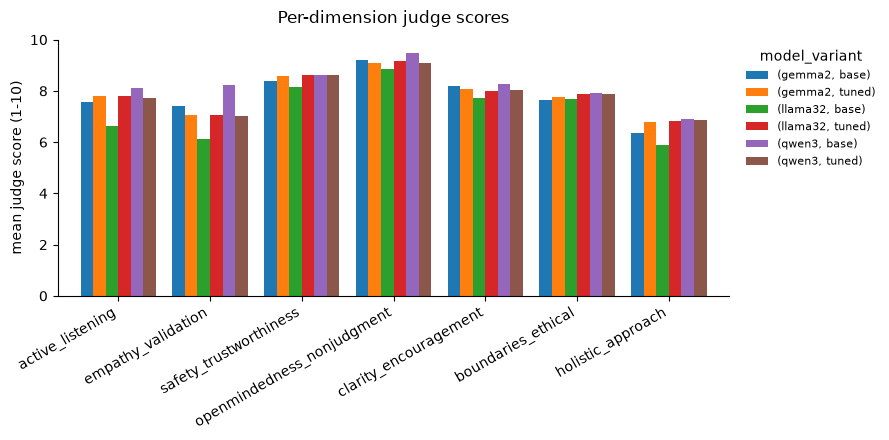

In [5]:
# Charts: overall mean judge score + per-dimension profile (tuned vs base)
V_COLORS = {"tuned": "#EE7733", "base": "#BBBBBB"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

scores["overall"] = scores[llm_judge.DIMENSIONS].mean(axis=1)
agg = scores.groupby(["model", "variant"])["overall"].mean().reset_index()

x = np.arange(len(MODELS))
width = 0.35
plt.figure(figsize=(7.5, 4))
for k, variant in enumerate(VARIANTS):
    vals = [agg[(agg["model"] == m) & (agg["variant"] == variant)]["overall"].mean()
            for m in MODELS]
    vals = [0 if np.isnan(v) else v for v in vals]
    bars = plt.bar(x + (k - 0.5) * width, vals, width,
                   color=V_COLORS[variant], label=variant)
    plt.bar_label(bars, fmt="{:.2f}", fontsize=8)
plt.xticks(x, MODELS); plt.ylim(0, 10)
plt.ylabel("mean judge score (1-10)")
plt.title("LLM-judge overall score — tuned vs base", pad=12)
plt.legend(frameon=False); plt.tight_layout()
plt.savefig(RESULTS / "judge_overall.png", dpi=150, bbox_inches="tight")
plt.show()

dim_means = scores.groupby(["model", "variant"])[llm_judge.DIMENSIONS].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
dim_means.T.plot(kind="bar", ax=ax, width=0.82)
ax.set_ylabel("mean judge score (1-10)"); ax.set_ylim(0, 10)
ax.set_title("Per-dimension judge scores", pad=12)
ax.legend(title="model_variant", frameon=False, fontsize=8,
          loc="upper left", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(RESULTS / "judge_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Write judge_report.md
lines = ["# LLM-as-Judge Report (7 counseling dimensions, GLM-4.7-Flash)", "",
         f"Judged {len(SAMPLE_IDX)} seeded-sample questions from the SAME "
         "MentalChat16K test-set generations used by the metric evaluation "
         "(`results/generations/`).", "",
         "## Mean scores", "",
         scores.groupby(["model", "variant"])[llm_judge.DIMENSIONS + ["overall"]]
               .mean().round(2).to_markdown(), ""]
best = agg.loc[agg["overall"].idxmax()]
lines += [f"**Best overall:** {best['model']} ({best['variant']}) "
          f"at {best['overall']:.2f}/10", ""]
(RESULTS / "judge_report.md").write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {RESULTS / 'judge_report.md'}")

Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\llm_judge\judge_report.md
